In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib
import mlflow
import mlflow.sklearn
mlflow.lightgbm.autolog(disable=True)
import json
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
df=pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution : {df['Churn'].value_counts(normalize=True)}")

Dataset shape: (7043, 21)
Target distribution : Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce'
)

In [6]:
missing_pct=(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nTop 10 features by missing %:")
print(missing_pct.head(10))


Top 10 features by missing %:
TotalCharges      0.156183
gender            0.000000
SeniorCitizen     0.000000
Partner           0.000000
customerID        0.000000
Dependents        0.000000
tenure            0.000000
MultipleLines     0.000000
PhoneService      0.000000
OnlineSecurity    0.000000
dtype: float64


In [7]:
df['TotalCharges_missing'] = df['TotalCharges'].isna().astype(int)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [8]:
df.groupby('TotalCharges_missing')['Churn'].value_counts(normalize=True)

TotalCharges_missing  Churn
0                     No       0.734215
                      Yes      0.265785
1                     No       1.000000
Name: proportion, dtype: float64

In [9]:
df.drop(columns=['TotalCharges_missing'], inplace=True)

In [14]:
numerical_features= ['SeniorCitizen','tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features=['Partner','Dependents','Contract','PaymentMethod','InternetService','TechSupport','OnlineSecurity','OnlineBackup','DeviceProtection','StreamingTV','StreamingMovies','PhoneService','MultipleLines','PaperlessBilling']
features=numerical_features+categorical_features

In [15]:
df_default=df.copy()
df_default['Churn_binary']=df_default['Churn'].map({'No': 0, 'Yes': 1})
X=df_default[features].copy()
y=df_default['Churn_binary'].copy()

print(f"Selected features: {len(features)}")
print(f"Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

Selected features: 18
Numerical: 4, Categorical: 14


In [16]:
missing_pct=(X.isnull().sum() / len(X) * 100).sort_values(ascending=False)
print("Features by missing %:")
print(missing_pct)

Features by missing %:
SeniorCitizen       0.0
tenure              0.0
MonthlyCharges      0.0
TotalCharges        0.0
Partner             0.0
Dependents          0.0
Contract            0.0
PaymentMethod       0.0
InternetService     0.0
TechSupport         0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
StreamingTV         0.0
StreamingMovies     0.0
PhoneService        0.0
MultipleLines       0.0
PaperlessBilling    0.0
dtype: float64


train/validation split

### Train / Validation Split

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nVal target distribution:\n{y_val.value_counts(normalize=True)}")

Train size: 5634 (80.0%)
Val size: 1409 (20.0%)

Train target distribution:
Churn_binary
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Val target distribution:
Churn_binary
0    0.734564
1    0.265436
Name: proportion, dtype: float64



The dataset was divided into **80% training** and **20% validation** sets.

- Train size: **5634 samples**
- Validation size: **1409 samples**

Stratified sampling was used to preserve the original churn distribution in both datasets. This ensures that the model is trained and evaluated on data with similar class proportions, which is important for reliable performance evaluation.

### Baseline Model: Logistic Regression

Logistic Regression was used as the first baseline model due to its simplicity and interpretability.

Before training the model:
- Numerical features were **imputed using the median** and **scaled using StandardScaler**
- Categorical features were **encoded using One-Hot Encoding**

In [18]:
numerical_transformer=Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_transformer=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor=ColumnTransformer([
    ('num',numerical_transformer,numerical_features),
    ('cat',categorical_transformer,categorical_features)
])

pipeline= Pipeline([
    ('preprocessor',preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

In [19]:
pipeline.fit(X_train, y_train)
print("Training complete")

Training complete


In [20]:
y_train_pred_proba=pipeline.predict_proba(X_train)[:,1]
y_val_pred_proba=pipeline.predict_proba(X_val)[:,1]
y_val_pred=pipeline.predict(X_val)

train_auc_log=roc_auc_score(y_train,y_train_pred_proba)
val_auc_log=roc_auc_score(y_val,y_val_pred_proba)

precision_log=precision_score(y_val,y_val_pred)
recall_log=recall_score(y_val,y_val_pred)
f1_log=f1_score(y_val,y_val_pred)

print("Logistic Regression Results:")
print(f"Train ROC-AUC: {train_auc_log:.4f}")
print(f"Val ROC-AUC: {val_auc_log:.4f}")
print(f"Val Precision: {precision_log:.4f}")
print(f"Val Recall: {recall_log:.4f}")
print(f"Val F1-Score: {f1_log:.4f}")

Logistic Regression Results:
Train ROC-AUC: 0.8492
Val ROC-AUC: 0.8418
Val Precision: 0.5034
Val Recall: 0.7834
Val F1-Score: 0.6130


In [21]:
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[746 289]
 [ 81 293]]


### Logistic Regression Results

The confusion matrix on the validation set is:

- True Negatives: **746**
- False Positives: **289**
- False Negatives: **81**
- True Positives: **293**

The model correctly identifies **746 non-churn customers** and **293 churn customers**.

However, there are **81 churn customers incorrectly predicted as non-churn**, which is an important limitation since failing to detect churners can lead to lost revenue for the company.

Overall, the model provides a reasonable baseline but may still miss some customers who are likely to churn.

In [22]:
feature_names=(numerical_features+ pipeline.named_steps['preprocessor']
               .named_transformers_['cat']
               .named_steps['onehot']
               .get_feature_names_out(categorical_features).tolist())

coefficients = pipeline.named_steps['classifier'].coef_[0]
feature_importance=pd.DataFrame({
    'feature': feature_names,
    'coefficient':np.abs(coefficients)
}).sort_values('coefficient', ascending=False)

print("\n Top 10 Important Features (Logistic Regression):")
print(feature_importance.head(10))


 Top 10 Important Features (Logistic Regression):
                             feature  coefficient
1                             tenure     1.152952
10                 Contract_Two year     0.777991
16       InternetService_Fiber optic     0.701207
2                     MonthlyCharges     0.674528
8            Contract_Month-to-month     0.650575
15               InternetService_DSL     0.625882
3                       TotalCharges     0.487930
19   TechSupport_No internet service     0.279717
17                InternetService_No     0.279717
25  OnlineBackup_No internet service     0.279717


### Baseline Model: LightGBM

In addition to Logistic Regression, a **LightGBM model** was trained as a tree-based baseline.

LightGBM is capable of capturing **non-linear relationships** between features and the target variable and often performs better than linear models on structured tabular datasets.

Categorical features were converted into numerical mappings so that they could be processed by the LightGBM algorithm.

In [25]:
X_train_lgb=X_train.copy()
X_val_lgb = X_val.copy()

cat_mappings={}

for col in categorical_features:
    unique_vals=X_train_lgb[col].dropna().unique()
    mapping = {val: ide for ide, val in enumerate(unique_vals) }
    cat_mappings[col]=mapping
    X_train_lgb[col] = X_train_lgb[col].map(mapping)
    X_val_lgb[col] = X_val_lgb[col].map(mapping)

print(f"Categorical mappings created for {len(cat_mappings)} features")

Categorical mappings created for 14 features


In [26]:
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    class_weight='balanced',
    verbose=-1
)
lgb_model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)], eval_metric='auc')
print("Training complete")

Training complete


In [27]:
y_train_pred_proba_lgb = lgb_model.predict_proba(X_train_lgb)[:, 1]
y_val_pred_proba_lgb = lgb_model.predict_proba(X_val_lgb)[:, 1]
y_val_pred_lgb = lgb_model.predict(X_val_lgb)

train_auc_lgb = roc_auc_score(y_train, y_train_pred_proba_lgb)
val_auc_lgb = roc_auc_score(y_val, y_val_pred_proba_lgb)
precision_lgb = precision_score(y_val, y_val_pred_lgb)
recall_lgb = recall_score(y_val, y_val_pred_lgb)
f1_lgb = f1_score(y_val, y_val_pred_lgb)

print("LightGBM Results:")
print(f"Train ROC-AUC: {train_auc_lgb:.4f}")
print(f"Val ROC-AUC: {val_auc_lgb:.4f}")
print(f"Val Precision: {precision_lgb:.4f}")
print(f"Val Recall: {recall_lgb:.4f}")
print(f"Val F1-Score: {f1_lgb:.4f}")


LightGBM Results:
Train ROC-AUC: 0.9754
Val ROC-AUC: 0.8265
Val Precision: 0.5355
Val Recall: 0.7059
Val F1-Score: 0.6090


In [28]:
cm_lgb=confusion_matrix(y_val, y_val_pred_lgb)
print("Confusion Matrix (Validation):")
print(cm_lgb)

Confusion Matrix (Validation):
[[806 229]
 [110 264]]


### LightGBM Results

The confusion matrix for the LightGBM model on the validation set is:

- True Negatives: **806**
- False Positives: **229**
- False Negatives: **110**
- True Positives: **264**

The model correctly predicts **806 non-churn customers** and **264 churn customers**.

Compared to Logistic Regression, LightGBM produces **fewer false positives (229 vs 289)**, meaning it is better at correctly identifying customers who will not churn. However, it has **more false negatives (110 vs 81)**, which means it misses more customers who actually churn.

In [29]:
feature_importance_lgb=pd.DataFrame({
    'feature':features,
    'importance':lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features (LightGBM):")
print(feature_importance_lgb.head(10))


Top 10 Important Features (LightGBM):
             feature  importance
2     MonthlyCharges        4081
3       TotalCharges        3628
1             tenure        2265
7      PaymentMethod         825
6           Contract         478
4            Partner         333
17  PaperlessBilling         316
5         Dependents         270
11      OnlineBackup         264
10    OnlineSecurity         251


In [30]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM'],
    'Train AUC': [train_auc_log, train_auc_lgb],
    'Val AUC': [val_auc_log, val_auc_lgb],
    'Precision': [precision_log, precision_lgb],
    'Recall': [recall_log, recall_lgb],
    'F1-Score': [f1_log, f1_lgb]
})

print("\nModel Comparison:")
print(results.to_string(index=False))


Model Comparison:
              Model  Train AUC  Val AUC  Precision   Recall  F1-Score
Logistic Regression   0.849209 0.841835   0.503436 0.783422  0.612971
           LightGBM   0.975403 0.826453   0.535497 0.705882  0.608997


### Model Comparison

The performance of Logistic Regression and LightGBM was compared using AUC, Precision, Recall, and F1-score. Both models show different strengths in churn prediction.

Logistic Regression achieved a **Train AUC of 0.849** and a **Validation AUC of 0.842**, showing consistent performance between training and validation datasets. It also produced a **higher recall (0.783)** compared to LightGBM, meaning it is better at identifying customers who actually churn.

LightGBM achieved a **higher Train AUC (0.975)** but a lower **Validation AUC (0.826)**, which suggests that the model may be slightly overfitting the training data. However, it shows a slightly **higher precision (0.535 vs 0.503)**, meaning its churn predictions are somewhat more accurate.

Overall, Logistic Regression provides **better generalization and higher recall**, while LightGBM achieves **slightly better precision but lower validation performance**.

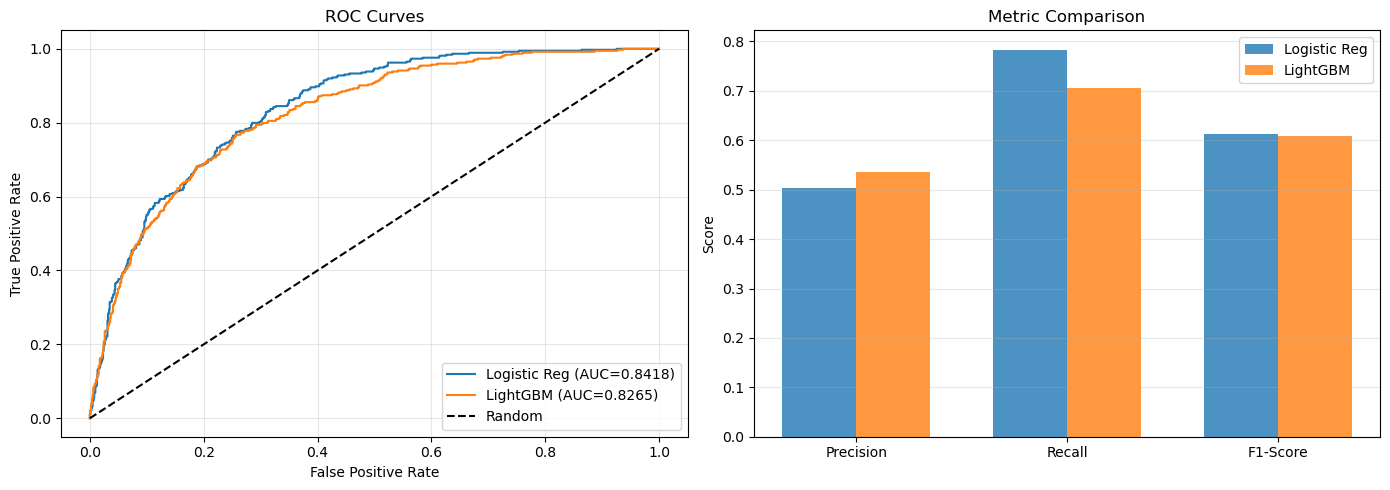

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_log, tpr_log, _ = roc_curve(y_val, y_val_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_val_pred_proba_lgb)

axes[0].plot(fpr_log, tpr_log, label=f'Logistic Reg (AUC={val_auc_log:.4f})')
axes[0].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC={val_auc_lgb:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

metrics = ['Precision', 'Recall', 'F1-Score']
log_scores = [precision_log, recall_log, f1_log]
lgb_scores = [precision_lgb, recall_lgb, f1_lgb]

x = np.arange(len(metrics))
width = 0.35
axes[1].bar(x - width/2, log_scores, width, label='Logistic Reg', alpha=0.8)
axes[1].bar(x + width/2, lgb_scores, width, label='LightGBM', alpha=0.8)
axes[1].set_ylabel('Score')
axes[1].set_title('Metric Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [44]:
joblib.dump(pipeline, '../models/baseline_logistic_v1.pkl')
print("Saved: models/baseline_logistic_v1.pkl")

lgb_artifacts = {
    'model': lgb_model,
    'cat_mappings': cat_mappings,
    'features': features,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features
}
joblib.dump(lgb_artifacts, '../models/baseline_lightgbm_v1.pkl')
print("Saved: models/baseline_lightgbm_v1.pkl")


Saved: models/baseline_logistic_v1.pkl
Saved: models/baseline_lightgbm_v1.pkl


In [46]:
mlflow_tracking_uri = os.path.join(os.getcwd(), 'mlruns')
mlflow.set_tracking_uri(f"file:///{mlflow_tracking_uri}")

mlflow.set_experiment("baseline_models")
with mlflow.start_run(run_name="logistic_regression_v1"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight","balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("n_features", len(features))

    mlflow.log_metric("train_auc", train_auc_log)
    mlflow.log_metric("val_auc", val_auc_log)
    mlflow.log_metric("val_precision", precision_log)
    mlflow.log_metric("val_recall", recall_log)
    mlflow.log_metric("val_f1", f1_log)

    mlflow.sklearn.log_model(pipeline, name = "model")

    feature_config= {
        'all_features' : features,
        'numerical_features' : numerical_features,
        'categorical_features' : categorical_features
    }
    with open('features_log.json','w') as f :
        json.dump(feature_config, f, indent=2)
    mlflow.log_artifact('features_log.json')

    cm_data={
        'confusion_matrix' : cm.tolist(),
        'labels' : ['No Deafult', 'Default']
    }
    with open('confusion_matrix_log.json','w') as f :
        json.dump(cm_data, f, indent=2)
    mlflow.log_artifact('confusion_matrix_log.json')

print("Logged Logistic Regression to MLflow")

Logged Logistic Regression to MLflow


In [48]:
with mlflow.start_run(run_name="lightgbm_v1"):
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 7)
    mlflow.log_param("n_features", len(features))
    
    mlflow.log_metric("train_auc", train_auc_lgb)
    mlflow.log_metric("val_auc", val_auc_lgb)
    mlflow.log_metric("val_precision", precision_lgb)
    mlflow.log_metric("val_recall", recall_lgb)
    mlflow.log_metric("val_f1", f1_lgb)
    
    mlflow.sklearn.log_model(lgb_model, name = "model")
    
    with open('features_lgb.json', 'w') as f:
        json.dump(feature_config, f, indent=2)
    mlflow.log_artifact('features_lgb.json')
    
    joblib.dump(cat_mappings, 'cat_mappings.pkl')
    mlflow.log_artifact('cat_mappings.pkl')
    
    cm_data = {
        'confusion_matrix': cm_lgb.tolist(),
        'labels': ['No Default', 'Default']
    }
    with open('confusion_matrix_lgb.json', 'w') as f:
        json.dump(cm_data, f, indent=2)
    mlflow.log_artifact('confusion_matrix_lgb.json')
    
    feature_importance_lgb.to_csv('feature_importance_lgb.csv', index=False)
    mlflow.log_artifact('feature_importance_lgb.csv')

print("Logged LightGBM to MLflow")

# Cleanup temporary files
for f in ['features_log.json', 'features_lgb.json', 'cat_mappings.pkl', 
          'confusion_matrix_log.json', 'confusion_matrix_lgb.json', 
          'feature_importance_lgb.csv']:
    if os.path.exists(f):
        os.remove(f)

Logged LightGBM to MLflow
